C:\Users\aiap2\AppData\Local\Temp\ipykernel_5280\2556954288.py:107: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(t_eval), P_0v, label='P_0v')
C:\Users\aiap2\AppData\Local\Temp\ipykernel_5280\2556954288.py:108: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(t_eval), P_2c, label='P_2c')


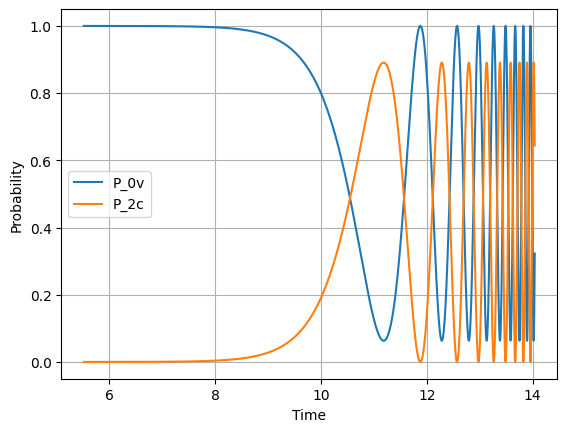

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# # Parameters for 2(a)
# wb = 1
# lam = 0.03      # λ
# Omega = 0.003   # Ω
# n = 2

# Delta = -1.9990901803607213

#Parameters for 2(b)
wb = 1
lam = 0.1      # λ
Omega = 0.003   # Ω
n = 2

Delta = -1.9899799599198396

n_max = 15   # IMPORTANT: must be >= n

# ---------- Operators ----------

# Phonon operators
b = np.zeros((n_max+1, n_max+1), dtype=complex)
for i in range(1, n_max+1):
    b[i-1, i] = np.sqrt(i)

bd = b.conj().T
num = bd @ b

# Identity (phonon)
I_ph = np.eye(n_max+1)

# QD operators
sigma = np.array([[0, 1],
                  [0, 0]], dtype=complex)

sigmad = sigma.conj().T
proj_c = sigmad @ sigma   # |c><c|
I_qd = np.eye(2)

# ---------- Tensor products ----------

def kron(a, b):
    return np.kron(a, b)

# Full operators
b_full = kron(I_qd, b)
bd_full = kron(I_qd, bd)
num_full = kron(I_qd, num)

sigma_full = kron(sigma, I_ph)
sigmad_full = kron(sigmad, I_ph)
proj_c_full = kron(proj_c, I_ph)

# ---------- Hamiltonian ----------

H = (
    wb * num_full
    + Delta * proj_c_full
    + lam * proj_c_full @ (bd_full + b_full)
    + Omega * (sigma_full + sigmad_full)
)

# ---------- Initial state |0,v> ----------

# |v> = [1,0], |c> = [0,1]
v = np.array([1, 0], dtype=complex)
phonon_0 = np.zeros(n_max+1)
phonon_0[0] = 1

psi0 = np.kron(v, phonon_0)

# ---------- Time evolution ----------

# Diagonalize once (fast evolution)
E, V = np.linalg.eigh(H)

def psi_t(t):
    return V @ (np.exp(-1j * E * t) * (V.conj().T @ psi0))

# Time grid
t_eval = np.linspace(0, 1.25e6, 5000)

psi_array = np.array([psi_t(t) for t in t_eval])

# ---------- Probabilities ----------

def projector(state_vec):
    return np.outer(state_vec, state_vec.conj())

# |0,v>
zero_v = np.kron(v, phonon_0)

# |2,c>
phonon_2 = np.zeros(n_max+1)
phonon_2[2] = 1
c = np.array([0, 1], dtype=complex)
two_c = np.kron(c, phonon_2)

P_0v = np.abs(psi_array @ zero_v.conj())**2
P_2c = np.abs(psi_array @ two_c.conj())**2


plt.plot(np.log(t_eval), P_0v, label='P_0v')
plt.plot(np.log(t_eval), P_2c, label='P_2c')

plt.xlabel('Time')
plt.ylabel('Probability')
plt.legend()
plt.grid()
plt.show()

In [2]:
#optimising delta

deltas = np.linspace(-2, -1.98, 500)
max_P2c = []

for Delta in deltas:
    # rebuild full H here
    H = (
        wb * num_full
        + Delta * proj_c_full
        + lam * proj_c_full @ (bd_full + b_full)
        + Omega * (sigma_full + sigmad_full)
    )

    E, V = np.linalg.eigh(H)

    def psi_t(t):
        return V @ (np.exp(-1j * E * t) * (V.conj().T @ psi0))

    psi_array = np.array([psi_t(t) for t in t_eval])

    # |2,c>
    P_2c = np.abs(psi_array @ two_c.conj())**2
    max_P2c.append(np.max(P_2c))

best_delta = deltas[np.argmax(max_P2c)]
print(best_delta)

-1.9899799599198396


C:\Users\aiap2\AppData\Local\Temp\ipykernel_21292\2076824363.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


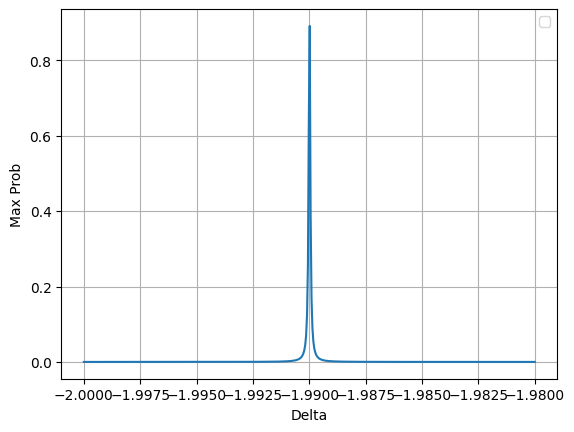

In [3]:
#Seeing the distribution of deltas

plt.plot(deltas, max_P2c)
plt.xlabel('Delta')
plt.ylabel('Max Prob')
plt.legend()
plt.grid()
plt.show()

C:\Users\aiap2\AppData\Local\Temp\ipykernel_21292\1355590359.py:96: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(t_eval), P_0v, label='P_0v')
C:\Users\aiap2\AppData\Local\Temp\ipykernel_21292\1355590359.py:97: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(t_eval), P_2c, label='P_2c')


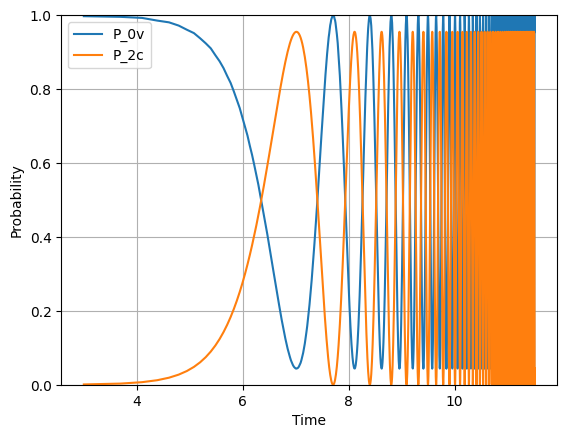

In [15]:
import numpy as np
from scipy.linalg import expm

# parameters
wb = 1.0
lam = 0.2        # strong coupling now
Omega = 0.05
g = lam / wb

n_max = 8

# phonon operators
b = np.zeros((n_max+1, n_max+1), dtype=complex)
for i in range(1, n_max+1):
    b[i-1, i] = np.sqrt(i)

bd = b.conj().T
num = bd @ b
I_ph = np.eye(n_max+1)

# QD operators
sigma = np.array([[0, 1],
                  [0, 0]], dtype=complex)
sigmad = sigma.conj().T
proj_c = sigmad @ sigma
I_qd = np.eye(2)

# tensor helpers
def kron(a, b):
    return np.kron(a, b)

# displacement operator
X = expm(g * (bd - b))
X_dag = X.conj().T

# full operators
num_full = kron(I_qd, num)
sigma_full = kron(sigma, I_ph)
sigmad_full = kron(sigmad, I_ph)
proj_c_full = kron(proj_c, I_ph)

X_full = kron(I_qd, X)
X_dag_full = kron(I_qd, X_dag)

# shifted detuning
Delta_eff = -1.958 - lam**2 / wb

# Hamiltonian (strong coupling form)
H = (
    wb * num_full
    + Delta_eff * proj_c_full
    + Omega * (sigma_full @ X_dag_full + sigmad_full @ X_full)
)

# ---------- Initial state |0,v> ----------

# |v> = [1,0], |c> = [0,1]
v = np.array([1, 0], dtype=complex)
phonon_0 = np.zeros(n_max+1)
phonon_0[0] = 1

psi0 = np.kron(v, phonon_0)

# ---------- Time evolution ----------

# Diagonalize once (fast evolution)
E, V = np.linalg.eigh(H)

def psi_t(t):
    return V @ (np.exp(-1j * E * t) * (V.conj().T @ psi0))

# Time grid
t_eval = np.linspace(0, 1e5, 5000)

psi_array = np.array([psi_t(t) for t in t_eval])

# ---------- Probabilities ----------

def projector(state_vec):
    return np.outer(state_vec, state_vec.conj())

# |0,v>
zero_v = np.kron(v, phonon_0)

# |2,c>
phonon_2 = np.zeros(n_max+1)
phonon_2[2] = 1
c = np.array([0, 1], dtype=complex)
two_c = np.kron(c, phonon_2)

P_0v = np.abs(psi_array @ zero_v.conj())**2
P_2c = np.abs(psi_array @ two_c.conj())**2

plt.ylim(0, 1)

plt.plot(np.log(t_eval), P_0v, label='P_0v')
plt.plot(np.log(t_eval), P_2c, label='P_2c')

plt.xlabel('Time')
plt.ylabel('Probability')
plt.legend()
plt.grid()
plt.show()

In [4]:
import numpy as np

# ----------- target state |2,c> -----------

phonon_2 = np.zeros(n_max+1)
phonon_2[2] = 1

c = np.array([0, 1], dtype=complex)
two_c = np.kron(c, phonon_2)

# ----------- evolution helper -----------

def max_population_for_delta(Delta):
    # rebuild Hamiltonian with this Delta
    
    Delta_eff = Delta - lam**2 / wb   # IMPORTANT (polaron shift)

    H = (
        wb * num_full
        + Delta_eff * proj_c_full
        + Omega * (sigma_full @ X_dag_full + sigmad_full @ X_full)
    )

    # diagonalize
    E, V = np.linalg.eigh(H)

    # evolve
    psi_array = np.array([
        V @ (np.exp(-1j * E * t) * (V.conj().T @ psi0))
        for t in t_eval
    ])

    # compute P_2c
    P_2c = np.abs(psi_array @ two_c.conj())**2

    return np.max(P_2c)


# ----------- scan Δ -----------

# good initial guess (VERY important)
Delta_guess = -n * wb + lam**2 / wb

# scan window around it
deltas = np.linspace(Delta_guess - 0.002, Delta_guess + 0.002, 100)

results = []

for Delta in deltas:
    results.append(max_population_for_delta(Delta))

results = np.array(results)

# best Δ
best_delta = deltas[np.argmax(results)]

print("Best Delta =", best_delta)
print("Max P_2c =", np.max(results))

Best Delta = -1.958
Max P_2c = 0.95492260613415


C:\Users\aiap2\AppData\Local\Temp\ipykernel_27224\611090830.py:99: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(t_eval), P_0v, label='P_0v')
C:\Users\aiap2\AppData\Local\Temp\ipykernel_27224\611090830.py:100: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(t_eval), P_3c, label='P_3c')


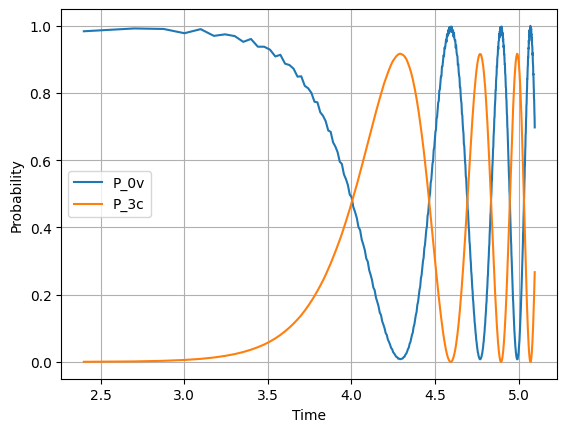

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

wb = 1
lam = 0.1      # λ
Omega = 0.07   # Ω
lam = 0.1
Omega = 0.2

Delta = -2.963063063063063

n_max = 15   # IMPORTANT: must be >= n

# ---------- Operators ----------

# Phonon operators
b = np.zeros((n_max+1, n_max+1), dtype=complex)
for i in range(1, n_max+1):
    b[i-1, i] = np.sqrt(i)

bd = b.conj().T
num = bd @ b

# Identity (phonon)
I_ph = np.eye(n_max+1)

# QD operators
sigma = np.array([[0, 1],
                  [0, 0]], dtype=complex)

sigmad = sigma.conj().T
proj_c = sigmad @ sigma   # |c><c|
I_qd = np.eye(2)

# ---------- Tensor products ----------

def kron(a, b):
    return np.kron(a, b)

# Full operators
b_full = kron(I_qd, b)
bd_full = kron(I_qd, bd)
num_full = kron(I_qd, num)

sigma_full = kron(sigma, I_ph)
sigmad_full = kron(sigmad, I_ph)
proj_c_full = kron(proj_c, I_ph)

# ---------- Hamiltonian ----------

H = (
    wb * num_full
    + Delta * proj_c_full
    + lam * proj_c_full @ (bd_full + b_full)
    + Omega * (sigma_full + sigmad_full)
)

# ---------- Initial state |0,v> ----------

# |v> = [1,0], |c> = [0,1]
v = np.array([1, 0], dtype=complex)
phonon_0 = np.zeros(n_max+1)
phonon_0[0] = 1

psi0 = np.kron(v, phonon_0)

# ---------- Time evolution ----------

# Diagonalize once (fast evolution)
E, V = np.linalg.eigh(H)

def psi_t(t):
    return V @ (np.exp(-1j * E * t) * (V.conj().T @ psi0))

# Time grid
t_eval = np.linspace(0, 1.25e5, 500)

psi_array = np.array([psi_t(t) for t in t_eval])

# ---------- Probabilities ----------

def projector(state_vec):
    return np.outer(state_vec, state_vec.conj())

# |0,v>
zero_v = np.kron(v, phonon_0)

# |2,c>
phonon_3 = np.zeros(n_max+1)
phonon_3[3] = 1
c = np.array([0, 1], dtype=complex)
three_c = np.kron(c, phonon_3)

P_0v = np.abs(psi_array @ zero_v.conj())**2
P_3c = np.abs(psi_array @ three_c.conj())**2


plt.plot(np.log10(t_eval), P_0v, label='P_0v')
plt.plot(np.log10(t_eval), P_3c, label='P_3c')

plt.xlabel('Time')
plt.ylabel('Probability')
plt.legend()
plt.grid()
plt.show()

c:\Users\aiap2\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\aiap2\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\aiap2\AppData\Local\Temp\ipykernel_27224\599754363.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


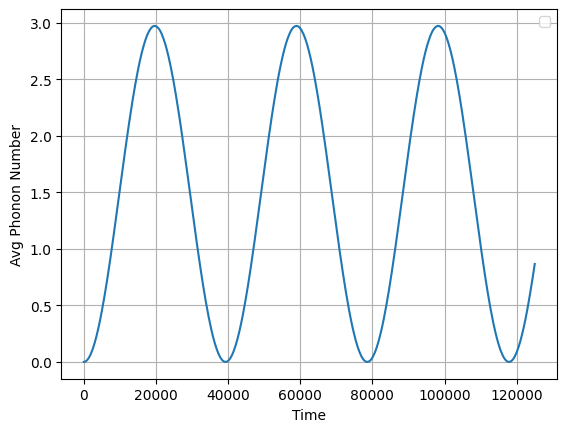

In [2]:
cou = [b_full@psi for psi in psi_array]
avgp = [x.conj().T@x for x in cou]
plt.plot(t_eval, avgp)

plt.xlabel('Time')
plt.ylabel('Avg Phonon Number')
plt.legend()
plt.grid()
plt.show()